# Ego4D v2 full_scale 数据探索

本 notebook 用于探索 `/mnt/data_oss/raw_data/Ego4d/v2/full_scale` 目录下的视频数据：

- 数据概览（文件数量、总大小、命名规则）
- 视频时长分布（直方图、CDF、分位数）
- 文件大小、分辨率、帧率等元信息
- 交互式视频预览（选视频 + 拖动时间轴看帧）

In [1]:
import json
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from tqdm.notebook import tqdm

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

DATA_ROOT = Path('/mnt/data_oss/raw_data/Ego4d')
FULL_SCALE_DIR = DATA_ROOT / 'v2/full_scale'
METADATA_PATH = DATA_ROOT / 'ego4d.json'
CACHE_PATH = Path('ego4d_full_scale_cache.csv')

print(f'数据目录: {FULL_SCALE_DIR}')
print(f'目录存在: {FULL_SCALE_DIR.exists()}')

数据目录: /mnt/data_oss/raw_data/Ego4d/v2/full_scale
目录存在: True


## 1. 扫描本地文件 & 加载元数据

In [2]:
def probe_video(path: Path) -> dict:
    """用 OpenCV 读取视频基础信息（用于与元数据交叉验证）。"""
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return {'probe_ok': False}
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    dur = frames / fps if fps > 0 else 0
    cap.release()
    return {
        'probe_ok': True,
        'probe_fps': fps,
        'probe_frames': int(frames),
        'probe_duration_sec': dur,
        'probe_width': w,
        'probe_height': h,
    }


def build_dataframe(use_cache: bool = True, probe_local: bool = False, max_probe: int | None = None) -> pd.DataFrame:
    if use_cache and CACHE_PATH.exists() and not probe_local:
        print(f'从缓存加载: {CACHE_PATH}')
        return pd.read_csv(CACHE_PATH)

    print('加载 ego4d.json 元数据...')
    with open(METADATA_PATH) as f:
        meta = json.load(f)
    meta_by_uid = {v['video_uid']: v for v in meta['videos']}

    mp4_files = sorted(FULL_SCALE_DIR.glob('*.mp4'))
    print(f'本地 mp4 数量: {len(mp4_files)}')

    rows = []
    for p in tqdm(mp4_files, desc='构建数据表'):
        uid = p.stem
        m = meta_by_uid.get(uid, {})
        vm = m.get('video_metadata', {}) or {}
        row = {
            'video_uid': uid,
            'filename': p.name,
            'filepath': str(p),
            'file_size_mb': p.stat().st_size / 1e6,
            'duration_sec': m.get('duration_sec'),
            'fps': vm.get('fps'),
            'num_frames': vm.get('num_frames'),
            'width': vm.get('display_resolution_width') or vm.get('sample_resolution_width'),
            'height': vm.get('display_resolution_height') or vm.get('sample_resolution_height'),
            'video_codec': vm.get('video_codec'),
            'scenarios': '; '.join(m.get('scenarios') or []),
            'video_source': m.get('video_source'),
            'device': m.get('device'),
            'split_fho': m.get('split_fho'),
            'split_em': m.get('split_em'),
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    if probe_local:
        targets = mp4_files[:max_probe] if max_probe else mp4_files
        print(f'OpenCV 探测 {len(targets)} 个视频（较慢，可选）...')
        probe_rows = []
        with ThreadPoolExecutor(max_workers=8) as ex:
            futures = {ex.submit(probe_video, p): p.stem for p in targets}
            for fut in tqdm(as_completed(futures), total=len(futures), desc='探测视频'):
                uid = futures[fut]
                probe_rows.append({'video_uid': uid, **fut.result()})
        probe_df = pd.DataFrame(probe_rows)
        df = df.merge(probe_df, on='video_uid', how='left')

    df.to_csv(CACHE_PATH, index=False)
    print(f'已缓存到 {CACHE_PATH}')
    return df


# 默认从元数据快速构建（约 1 秒）
df = build_dataframe(use_cache=True, probe_local=False)
df.head()

从缓存加载: ego4d_full_scale_cache.csv


,video_uid,file_size_mb,duration_sec,fps,width,height,video_source
0,000a3525-6c98-4650-aaab-be7d2c7b9402,43.814225,21.43,30.0,1920.0,1440.0,cmu
1,000cd456-ff8d-499b-b0c1-4acead128a8b,244.010466,958.10,30.0,1920.0,1440.0,bristol
2,002ad105-bd9a-4858-953e-54e88dc7587e,122.084903,1063.20,30.0,1440.0,1080.0,kaust
3,002c3b5c-ed86-4af3-99a1-4b497b7c8a86,655.684357,2757.97,30.0,1440.0,1080.0,kaust
4,002d2729-df71-438d-8396-5895b349e8fd,718.253558,3571.40,30.0,1440.0,1080.0,kaust


## 2. 数据概览

In [3]:
n_videos = len(df)
total_size_gb = df['file_size_mb'].sum() / 1024
total_hours = df['duration_sec'].sum() / 3600

overview = pd.DataFrame({
    '指标': [
        '视频数量', '总磁盘占用 (GB)', '总时长 (小时)',
        '平均时长 (分钟)', '中位时长 (分钟)',
        '最短 (秒)', '最长 (分钟)', '平均文件大小 (MB)'
    ],
    '数值': [
        f'{n_videos:,}',
        f'{total_size_gb:,.1f}',
        f'{total_hours:,.1f}',
        f"{df['duration_sec'].mean() / 60:.1f}",
        f"{df['duration_sec'].median() / 60:.1f}",
        f"{df['duration_sec'].min():.1f}",
        f"{df['duration_sec'].max() / 60:.1f}",
        f"{df['file_size_mb'].mean():.1f}",
    ]
})
display(overview)

print('\n文件命名规则: {video_uid}.mp4  (UUID 格式)')
print('示例文件:')
for p in sorted(FULL_SCALE_DIR.glob('*.mp4'))[:3]:
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.1f} MB)')

,指标,数值
0,视频数量,"2,977"
1,总磁盘占用 (GB),"2,329.6"
2,总时长 (小时),"1,393.2"
3,平均时长 (分钟),28.1
4,中位时长 (分钟),19.2
5,最短 (秒),11.6
6,最长 (分钟),423.6
7,平均文件大小 (MB),801.3



文件命名规则: {video_uid}.mp4  (UUID 格式)
示例文件:
  000a3525-6c98-4650-aaab-be7d2c7b9402.mp4  (43.8 MB)
  000cd456-ff8d-499b-b0c1-4acead128a8b.mp4  (244.0 MB)
  002ad105-bd9a-4858-953e-54e88dc7587e.mp4  (122.1 MB)


## 3. 视频时长分布

,分位数,时长 (秒),时长 (分钟)
0,P5,103.5,1.72
1,P10,199.1,3.32
2,P25,545.4,9.09
3,P50,1152.7,19.21
4,P75,2030.0,33.83
5,P90,3667.0,61.12
6,P95,4784.2,79.74
7,P99,10637.0,177.28


/tmp/ipykernel_14338/3000298284.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['duration_min'], vert=True)
/tmp/ipykernel_14338/3000298284.py:33: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14338/3000298284.py:33: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14338/3000298284.py:33: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14338/3000298284.py:33: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14338/3000298284.py:33: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layo

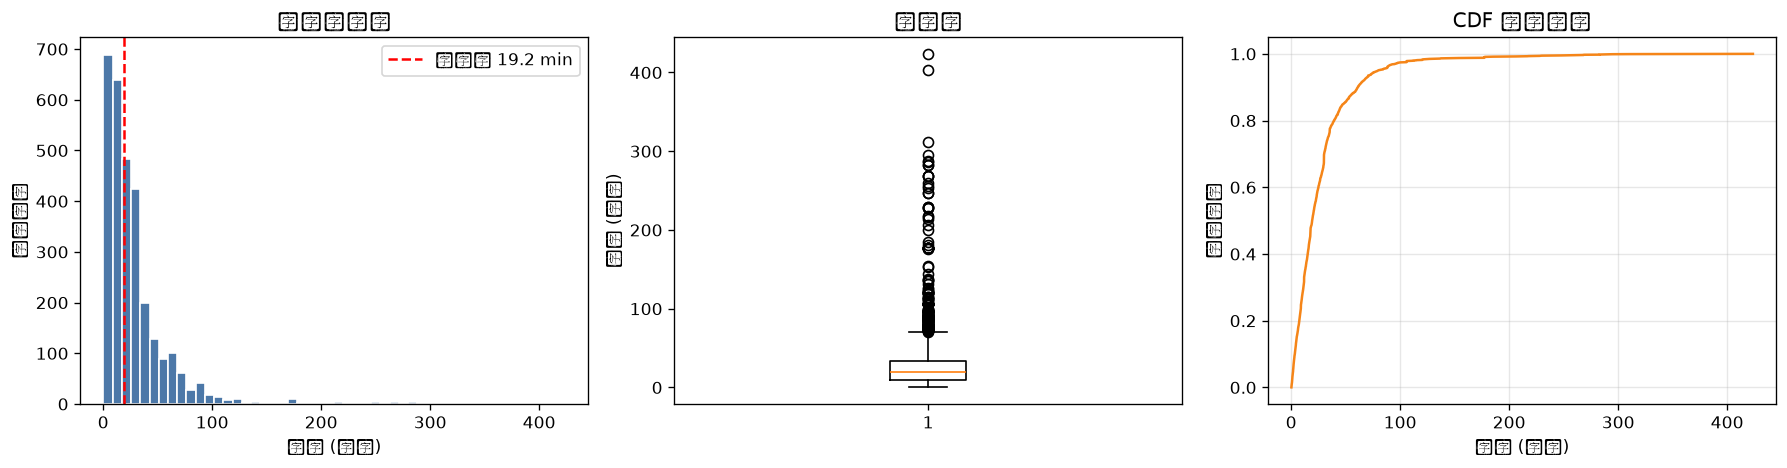

In [4]:
df['duration_min'] = df['duration_sec'] / 60

percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
pct = df['duration_sec'].quantile([p / 100 for p in percentiles])
pct_df = pd.DataFrame({
    '分位数': [f'P{p}' for p in percentiles],
    '时长 (秒)': pct.values.round(1),
    '时长 (分钟)': (pct.values / 60).round(2),
})
display(pct_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['duration_min'], bins=50, color='#4C78A8', edgecolor='white')
axes[0].set_xlabel('时长 (分钟)')
axes[0].set_ylabel('视频数量')
axes[0].set_title('时长直方图')
axes[0].axvline(df['duration_min'].median(), color='red', ls='--', label=f"中位数 {df['duration_min'].median():.1f} min")
axes[0].legend()

axes[1].boxplot(df['duration_min'], vert=True)
axes[1].set_ylabel('时长 (分钟)')
axes[1].set_title('箱线图')

sorted_dur = np.sort(df['duration_sec'].values)
cdf = np.arange(1, len(sorted_dur) + 1) / len(sorted_dur)
axes[2].plot(sorted_dur / 60, cdf, color='#F58518')
axes[2].set_xlabel('时长 (分钟)')
axes[2].set_ylabel('累积比例')
axes[2].set_title('CDF 累积分布')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 交互式 Plotly 直方图（可缩放、悬停查看）
fig = px.histogram(
    df, x='duration_min', nbins=60,
    title='Ego4D full_scale 视频时长分布（交互式）',
    labels={'duration_min': '时长 (分钟)', 'count': '视频数量'},
    marginal='box',
    color_discrete_sequence=['#4C78A8'],
)
fig.update_layout(bargap=0.05, height=450)
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [7]:
# 按时长区间统计
bins = [0, 1, 5, 10, 20, 30, 60, 120, 240, float('inf')]
labels = ['<1min', '1-5min', '5-10min', '10-20min', '20-30min', '30-60min', '1-2h', '2-4h', '>4h']
df['duration_bucket'] = pd.cut(df['duration_min'], bins=bins, labels=labels, right=False)

bucket_counts = df['duration_bucket'].value_counts().reindex(labels)
bucket_pct = (bucket_counts / len(df) * 100).round(1)

bucket_df = pd.DataFrame({'区间': labels, '数量': bucket_counts.values, '占比 (%)': bucket_pct.values})
display(bucket_df)

fig = px.bar(
    bucket_df, x='区间', y='数量', text='占比 (%)',
    title='时长区间分布',
    color='数量', color_continuous_scale='Blues',
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(height=400, showlegend=False)
fig.show()

,区间,数量,占比 (%)
0,<1min,75,2.5
1,1-5min,369,12.4
2,5-10min,370,12.4
3,10-20min,722,24.3
4,20-30min,469,15.8
5,30-60min,653,21.9
6,1-2h,264,8.9
7,2-4h,39,1.3
8,>4h,16,0.5


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 4. 文件大小 & 分辨率

In [8]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('文件大小分布 (MB)', '分辨率分布'))

fig.add_trace(go.Histogram(x=df['file_size_mb'], nbinsx=50, name='文件大小'), row=1, col=1)

df['resolution'] = df['width'].astype('Int64').astype(str) + 'x' + df['height'].astype('Int64').astype(str)
res_counts = df['resolution'].value_counts().head(10)
fig.add_trace(go.Bar(x=res_counts.index, y=res_counts.values, name='分辨率'), row=1, col=2)

fig.update_layout(height=380, showlegend=False, title_text='文件大小与分辨率')
fig.show()

print('帧率分布:')
display(df['fps'].value_counts().head(10).to_frame('数量'))

print('\n视频来源 (video_source):')
display(df['video_source'].value_counts().head(10).to_frame('数量'))

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 5. 时长 vs 文件大小

In [9]:
fig = px.scatter(
    df, x='duration_min', y='file_size_mb',
    opacity=0.5, hover_data=['video_uid', 'resolution', 'fps'],
    title='视频时长 vs 文件大小',
    labels={'duration_min': '时长 (分钟)', 'file_size_mb': '文件大小 (MB)'},
)
fig.update_layout(height=450)
fig.show()

df['mb_per_min'] = df['file_size_mb'] / df['duration_min'].replace(0, np.nan)
print(f"码率近似 (MB/min): 均值={df['mb_per_min'].mean():.1f}, 中位数={df['mb_per_min'].median():.1f}")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 6. 交互式视频预览

选择视频 UID，拖动时间滑块查看对应帧。

In [5]:
uid_to_path = dict(zip(df['video_uid'], df['filepath']))
uid_options = sorted(df['video_uid'].tolist())


def read_frame(video_path: str, timestamp_sec: float):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None, {}
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_idx = int(timestamp_sec * fps)
    frame_idx = max(0, min(frame_idx, total_frames - 1))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ok, frame = cap.read()
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    if not ok:
        return None, {}
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    info = {'fps': fps, 'frame_idx': frame_idx, 'total_frames': total_frames, 'width': w, 'height': h}
    return frame_rgb, info


uid_dropdown = widgets.Dropdown(options=uid_options, description='视频 UID:', layout=widgets.Layout(width='600px'))
time_slider = widgets.FloatSlider(value=0, min=0, max=60, step=1, description='时间 (秒):', continuous_update=False, readout_format='.0f')
info_html = widgets.HTML()
out = widgets.Output()


def update_preview(change=None):
    uid = uid_dropdown.value
    row = df[df['video_uid'] == uid].iloc[0]
    path = uid_to_path[uid]
    max_sec = float(row['duration_sec'])

    if time_slider.max != max_sec:
        time_slider.max = max_sec
    if time_slider.value > max_sec:
        time_slider.value = 0

    t = time_slider.value
    frame, probe = read_frame(path, t)

    info_html.value = (
        f"<b>{uid}</b> | 时长: {row['duration_sec']:.1f}s ({row['duration_min']:.1f} min) | "
        f"大小: {row['file_size_mb']:.1f} MB | 分辨率: {row['width']}x{row['height']} | "
        f"FPS: {row['fps']} | 来源: {row['video_source']}"
    )

    with out:
        clear_output(wait=True)
        if frame is None:
            print('无法读取视频帧')
            return
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(frame)
        ax.set_title(f't={t:.0f}s  frame={probe.get("frame_idx", "?")}/{probe.get("total_frames", "?")}')
        ax.axis('off')
        plt.show()


uid_dropdown.observe(update_preview, names='value')
time_slider.observe(update_preview, names='value')

display(widgets.VBox([uid_dropdown, time_slider, info_html, out]))
update_preview()

KeyError: 'filepath'

## 7. （可选）OpenCV 本地探测验证

元数据来自 `ego4d.json`，如需与本地 mp4 实际时长交叉验证，可运行下方代码（全量约 10 分钟）。

In [ ]:
# 取消注释以运行。建议先用 max_probe=100 抽样验证。
# df_probed = build_dataframe(use_cache=False, probe_local=True, max_probe=100)
# diff = (df_probed['probe_duration_sec'] - df_probed['duration_sec']).abs()
# print(f'抽样 {len(df_probed)} 个视频, 时长差异: mean={diff.mean():.2f}s, max={diff.max():.2f}s')
# display(df_probed[['video_uid','duration_sec','probe_duration_sec']].head())

## 8. 按条件筛选 & 排序

In [ ]:
min_dur = widgets.FloatText(value=0, description='最短 (min):')
max_dur = widgets.FloatText(value=60, description='最长 (min):')
sort_by = widgets.Dropdown(options=['duration_sec', 'file_size_mb', 'video_uid'], value='duration_sec', description='排序:')
ascending = widgets.Checkbox(value=False, description='升序')
filter_btn = widgets.Button(description='筛选', button_style='primary')
filter_out = widgets.Output()


def on_filter(_):
    with filter_out:
        clear_output(wait=True)
        sub = df[(df['duration_min'] >= min_dur.value) & (df['duration_min'] <= max_dur.value)]
        sub = sub.sort_values(sort_by.value, ascending=ascending.value)
        print(f'匹配 {len(sub)} / {len(df)} 个视频')
        display(sub[['video_uid', 'duration_min', 'file_size_mb', 'width', 'height', 'fps', 'video_source']].head(20))


filter_btn.on_click(on_filter)
display(widgets.HBox([min_dur, max_dur, sort_by, ascending, filter_btn]))
display(filter_out)
on_filter(None)